In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

2026-06-27 18:51:35.224925: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782586295.542521      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782586295.637990      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782586296.364698      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782586296.364758      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782586296.364768      17 computation_placer.cc:177] computation placer alr

In [2]:
df=pd.read_csv('/kaggle/input/datasets/metinmekiabullrahman/diabetes-detection/PIMA.csv')

In [3]:
df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [10]:
df['Outcome'].value_counts(normalize=True).round(3)

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

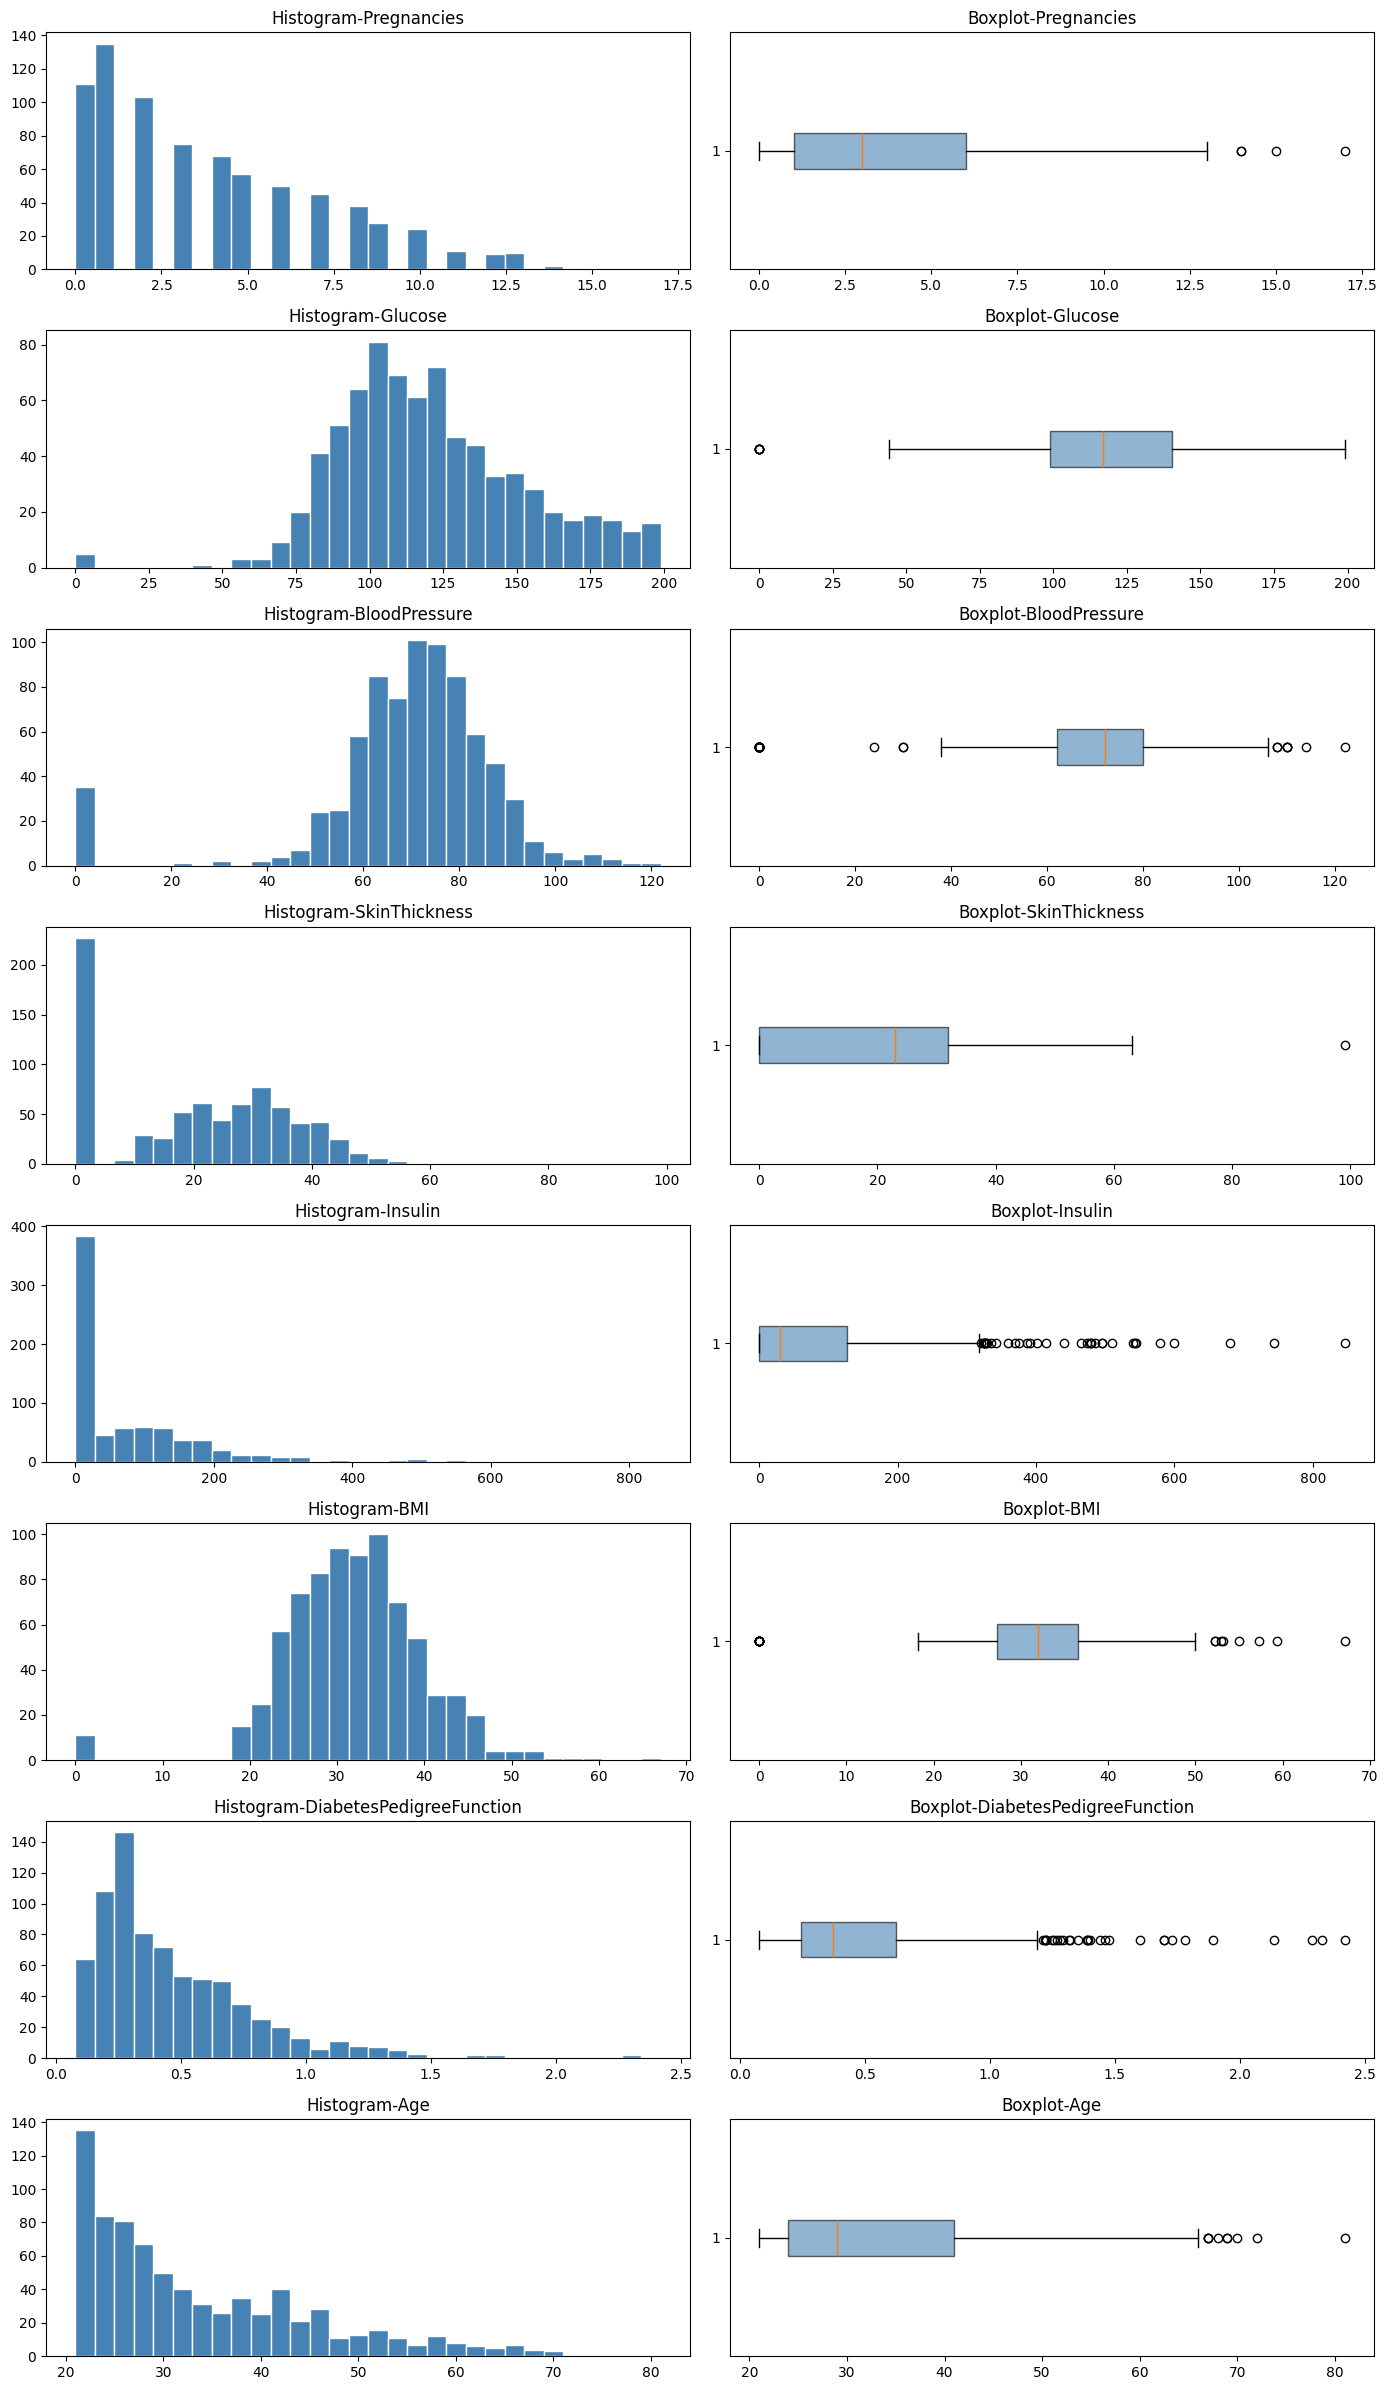

In [11]:
features=df.columns.drop('Outcome')

fig, axes = plt.subplots(len(features),2,figsize=(14,len(features)*3))

for i,col in enumerate(features):
    axes[i,0].hist(df[col],bins=30,color='steelblue',edgecolor='white')
    axes[i,0].set_title(f"Histogram-{col}")
    axes[i,1].boxplot(df[col],vert=False,patch_artist=True,boxprops=dict(facecolor='steelblue',alpha=0.6))
    axes[i,1].set_title(f"Boxplot-{col}")

plt.tight_layout()
plt.show()

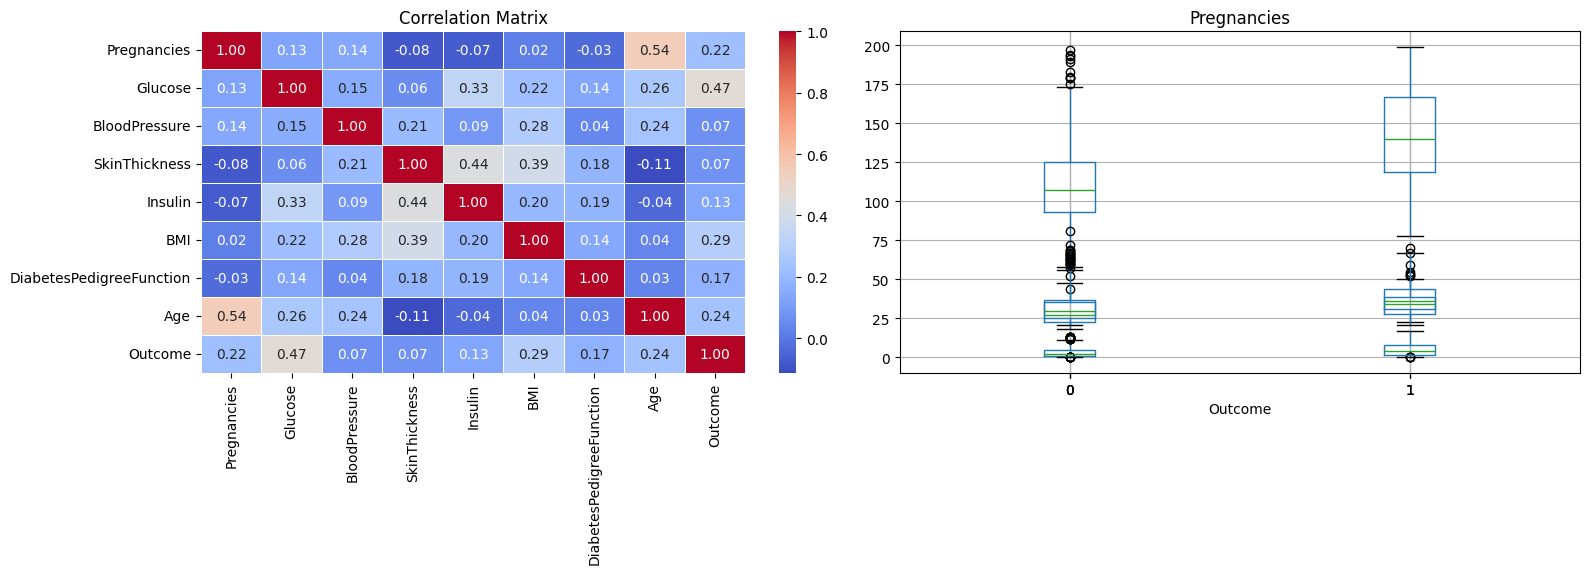

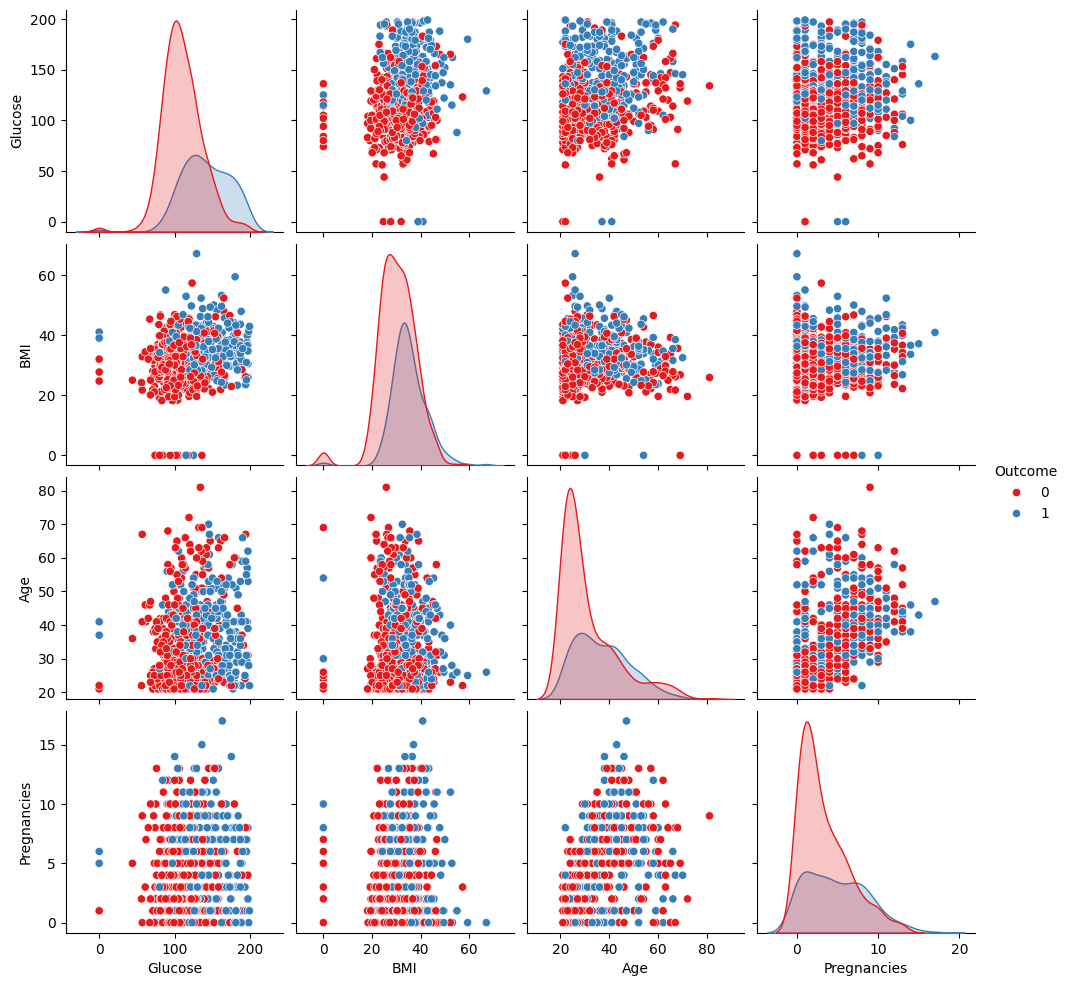

Correlation with Outcome:
 Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Matrix')

top_features = corr['Outcome'].drop('Outcome').abs().nlargest(4).index
for col in top_features:
    df.boxplot(column=col, by='Outcome', ax=axes[1])
plt.suptitle('')
plt.tight_layout()
plt.show()

top4 = df[list(top_features) + ['Outcome']]
sns.pairplot(top4, hue='Outcome', palette='Set1', diag_kind='kde')
plt.show()

print('Correlation with Outcome:\n', corr['Outcome'].drop('Outcome').sort_values(ascending=False))

In [13]:
zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero counts:')
for col in zero_invalid:
    print(f'  {col}: {(df[col] == 0).sum()}')

df_clean = df.copy()
for col in zero_invalid:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

Zero counts:
  Glucose: 5
  BloodPressure: 35
  SkinThickness: 227
  Insulin: 374
  BMI: 11


In [14]:
df_feat = df_clean.copy()

df_feat['BMI_Category'] = pd.cut(
    df_feat['BMI'],bins=[0,18.5,25,30,100],labels=[0,1,2,3]).astype(int)

df_feat['Age_Category'] = pd.cut(
    df_feat['Age'],bins=[0,30,45,60,100],labels=[0,1,2,3]).astype(int)

df_feat['Glucose_BMI'] = df_feat['Glucose']*df_feat['BMI']
df_feat['Insulin_Glucose_Ratio']= df_feat['Insulin']/(df_feat['Glucose']+ 1e-6)

In [15]:
X=df_feat.drop('Outcome',axis=1)
y=df_feat['Outcome']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:',X_train_scaled.shape)
print('Test:',X_test_scaled.shape)

Train: (614, 12)
Test: (154, 12)


In [16]:
X_train_np=np.array(X_train_scaled)
X_test_np=np.array(X_test_scaled)
y_train_np=np.array(y_train)
y_test_np=np.array(y_test)

print('X_train:',X_train_np.shape,X_train_np.dtype)
print('X_test:',X_test_np.shape,X_test_np.dtype)
print('y_train:',y_train_np.shape,y_train_np.dtype)

X_train: (614, 12) float64
X_test: (154, 12) float64
y_train: (614,) int64


In [17]:
tf.random.set_seed(42)

model_basic = Sequential([
    Dense(
        64,
        activation='relu',
        kernel_regularizer=l2(0.001),
        input_shape=(X_train_np.shape[1],)
    ),

    Dropout(0.3),

    Dense(
        32,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])
model_basic.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_basic.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-27 18:52:00.942698: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

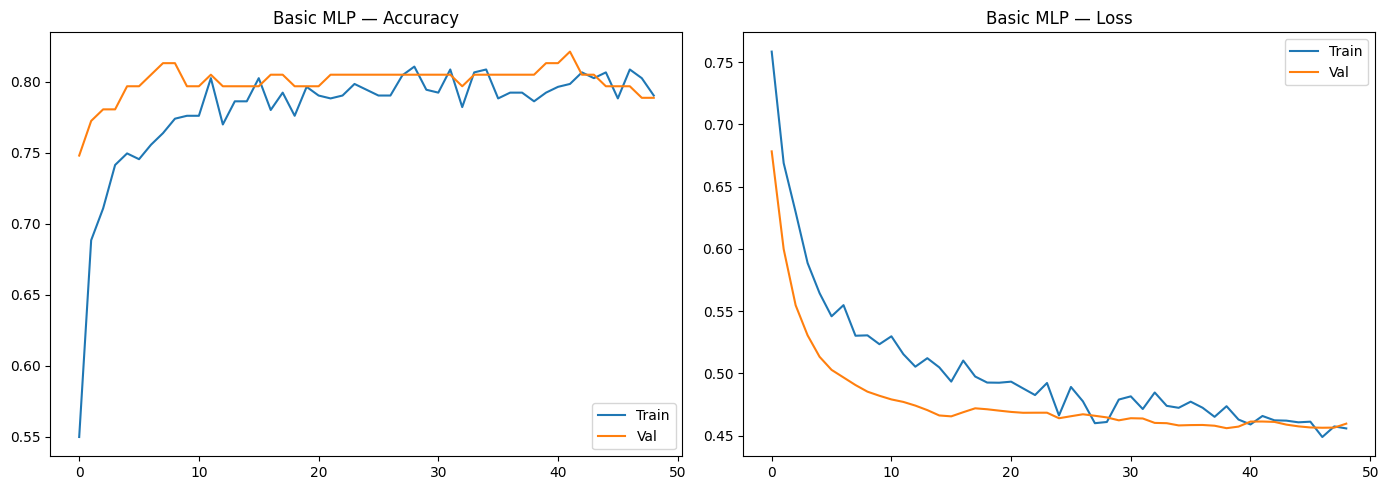

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_basic = model_basic.fit(
    X_train_np, y_train_np,
    epochs=100, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_basic.history['accuracy'], label='Train')
axes[0].plot(history_basic.history['val_accuracy'], label='Val')
axes[0].set_title('Basic MLP — Accuracy')
axes[0].legend()

axes[1].plot(history_basic.history['loss'], label='Train')
axes[1].plot(history_basic.history['val_loss'], label='Val')
axes[1].set_title('Basic MLP — Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
train_acc = history_basic.history['accuracy'][-1]
val_acc   = history_basic.history['val_accuracy'][-1]
gap = train_acc - val_acc

print(f'Train Acc: {train_acc:.4f}')
print(f'Val Acc  : {val_acc:.4f}')
print(f'Gap      : {gap:.4f}')
print('>> Overfitting detected' if gap > 0.05 else '>> No significant overfitting')

Train Acc: 0.7902
Val Acc  : 0.7886
Gap      : 0.0016
>> No significant overfitting


**DEEP MPL****

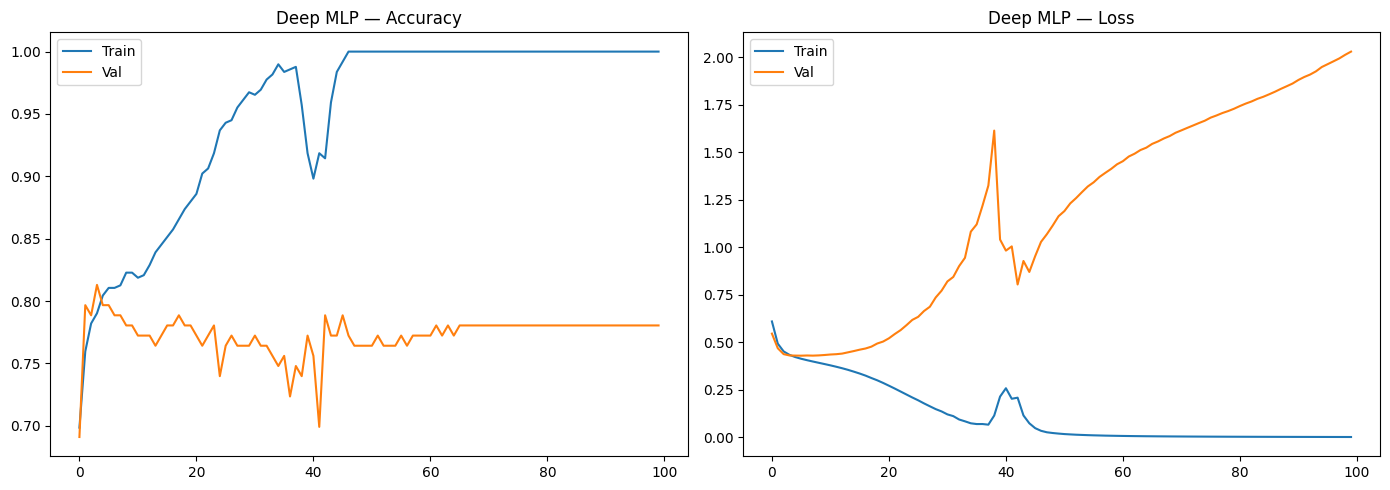

In [20]:
model_deep=Sequential([
    Dense(128,activation='relu',input_shape=(X_train_np.shape[1],)),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model_deep.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_deep=model_deep.fit(
    X_train_np,y_train_np,
    epochs=100,batch_size=32,
    validation_split=0.2,
    verbose=0
)

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(history_deep.history['accuracy'],label='Train')
axes[0].plot(history_deep.history['val_accuracy'], label='Val')
axes[0].set_title('Deep MLP — Accuracy')
axes[0].legend()

axes[1].plot(history_deep.history['loss'], label='Train')
axes[1].plot(history_deep.history['val_loss'], label='Val')
axes[1].set_title('Deep MLP — Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

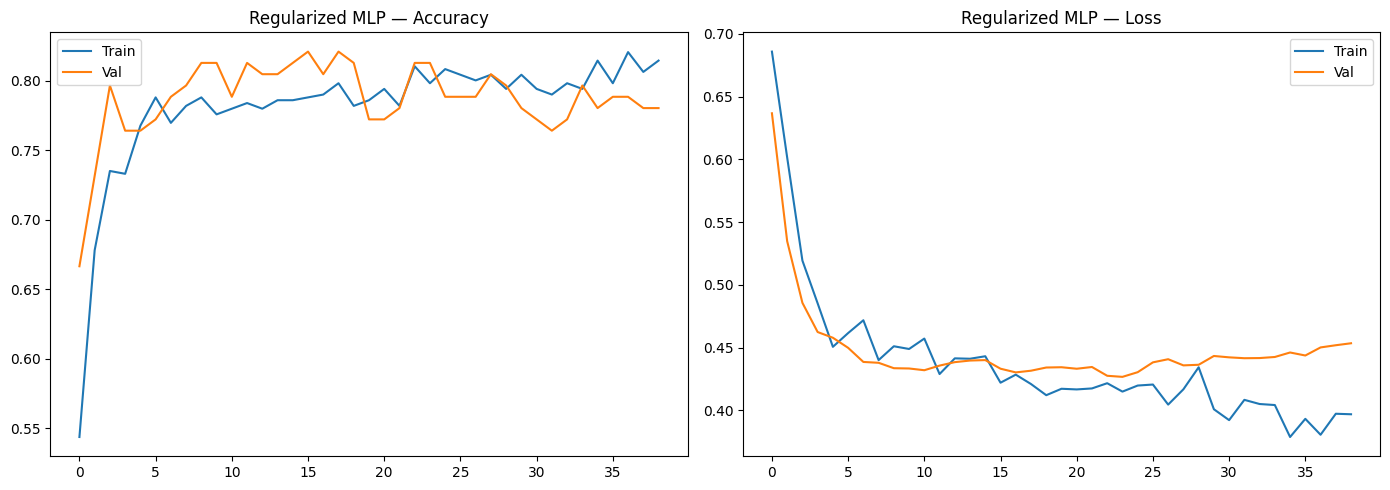

In [21]:
model_reg = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_np.shape[1],)),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.3),
    Dense(32,  activation='relu'),
    Dropout(0.2),
    Dense(16,  activation='relu'),
    Dense(1,   activation='sigmoid')
])

model_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_reg = model_reg.fit(
    X_train_np, y_train_np,
    epochs=200, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_reg.history['accuracy'], label='Train')
axes[0].plot(history_reg.history['val_accuracy'], label='Val')
axes[0].set_title('Regularized MLP — Accuracy')
axes[0].legend()

axes[1].plot(history_reg.history['loss'], label='Train')
axes[1].plot(history_reg.history['val_loss'], label='Val')
axes[1].set_title('Regularized MLP — Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
configs = [
    {'layers': [64, 32],       'dropout': 0.2, 'lr': 0.001,  'batch': 32},
    {'layers': [128, 64, 32],  'dropout': 0.3, 'lr': 0.001,  'batch': 32},
    {'layers': [64, 32],       'dropout': 0.3, 'lr': 0.0005, 'batch': 64},
    {'layers': [128, 64, 32],  'dropout': 0.4, 'lr': 0.001,  'batch': 16},
]

tune_results = []

for cfg in configs:
    m = Sequential()
    for i, n in enumerate(cfg['layers']):
        if i == 0:
            m.add(Dense(n, activation='relu', input_shape=(X_train_np.shape[1],)))
        else:
            m.add(Dense(n, activation='relu'))
        m.add(Dropout(cfg['dropout']))
    m.add(Dense(1, activation='sigmoid'))

    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss='binary_crossentropy', metrics=['accuracy']
    )

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    h = m.fit(X_train_np, y_train_np,
              epochs=150, batch_size=cfg['batch'],
              validation_split=0.2, callbacks=[es], verbose=0)

    y_p = (m.predict(X_test_np).flatten() >= 0.5).astype(int)
    tune_results.append({
        'Layers'  : str(cfg['layers']),
        'Dropout' : cfg['dropout'],
        'LR'      : cfg['lr'],
        'Batch'   : cfg['batch'],
        'Test Acc': round(accuracy_score(y_test_np, y_p), 4),
        'Recall'  : round(recall_score(y_test_np, y_p), 4),
        'F1'      : round(f1_score(y_test_np, y_p), 4)
    })

print(pd.DataFrame(tune_results).to_string(index=False))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7c5dbc405c60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
       Layers  Dropout     LR  Batch  Test Acc  Recall     F1
     [64, 32]      0.2 0.0010     32    0.7208  0.5185 0.5657
[128, 64, 32]      0.3 0.0010     32    0.7597  0.6481 0.6542
     [64, 32]      0.3 0.0005     64    0.7273  0.5741 0.5962
[128, 64, 32]      0.4 0.0010     16    0.7403  0.6481 0.6364


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
          Model  Acc Train  Acc Test  Precision  Recall  F1-Score
      MLP Basic     0.8062    0.7273     0.6200  0.5741    0.5962
       MLP Deep     0.9560    0.7403     0.6296  0.6296    0.6296
MLP Regularized     0.8029    0.7078     0.5849  0.5741    0.5794
  MLP Optimized     0.8046    0.7532     0.6538  0.6296    0.6415


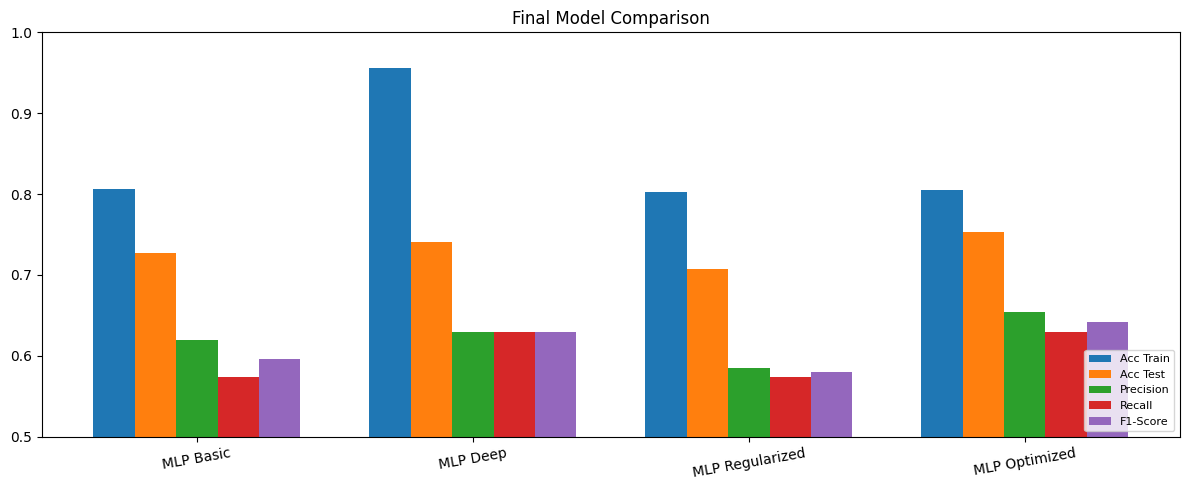

In [23]:
model_opt = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_np.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_opt.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='binary_crossentropy', metrics=['accuracy']
)
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_opt.fit(X_train_np, y_train_np, epochs=200, batch_size=32,
              validation_split=0.2, callbacks=[es], verbose=0)


def evaluate(model, name):
    train_pred = (model.predict(X_train_np).flatten() >= 0.5).astype(int)
    test_pred  = (model.predict(X_test_np).flatten() >= 0.5).astype(int)
    return {
        'Model'        : name,
        'Acc Train'    : round(accuracy_score(y_train_np, train_pred), 4),
        'Acc Test'     : round(accuracy_score(y_test_np, test_pred), 4),
        'Precision'    : round(precision_score(y_test_np, test_pred), 4),
        'Recall'       : round(recall_score(y_test_np, test_pred), 4),
        'F1-Score'     : round(f1_score(y_test_np, test_pred), 4)
    }

comparison = pd.DataFrame([
    evaluate(model_basic, 'MLP Basic'),
    evaluate(model_deep,  'MLP Deep'),
    evaluate(model_reg,   'MLP Regularized'),
    evaluate(model_opt,   'MLP Optimized')
])

print(comparison.to_string(index=False))

metrics = ['Acc Train', 'Acc Test', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison))
w = 0.15

fig, ax = plt.subplots(figsize=(12, 5))
for i, m in enumerate(metrics):
    ax.bar(x + i*w, comparison[m], w, label=m)
ax.set_xticks(x + w*2)
ax.set_xticklabels(comparison['Model'], rotation=10)
ax.set_ylim(0.5, 1.0)
ax.set_title('Final Model Comparison')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()